<a href="https://colab.research.google.com/github/mscids2024pranita-hue/goa-rainfall-arima/blob/main/03_stationarity_and_adf_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Stationarity Analysis & ADF Test
**Project:** Goa Rainfall Forecasting using SARIMA
**Data:** goa_monthly_rainfall_clean.csv
**Step:** Formally test stationarity and determine the value of d

In [1]:
!pip install netCDF4 xarray statsmodels -q
print("Done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 8.6 MB/s eta 0:00:00
Done


In [2]:
from google.colab import files
uploaded = files.upload()

Saving imd_rainfall-20260513T063252Z-3-001-20260530T092135Z-3-001.zip to imd_rainfall-20260513T063252Z-3-001-20260530T092135Z-3-001.zip


In [3]:
import zipfile, os, re
import xarray as xr
import numpy as np
import pandas as pd

# Unzip
with zipfile.ZipFile("imd_rainfall-20260513T063252Z-3-001-20260530T092135Z-3-001.zip", 'r') as z:
    z.extractall("imd_data")

DATA_DIR = "imd_data/imd_rainfall-20260513T063252Z-3-001/imd_rainfall/"
GOA_LAT_MIN, GOA_LAT_MAX = 14.9, 15.7
GOA_LON_MIN, GOA_LON_MAX = 73.7, 74.3

files_nc = sorted(os.listdir(DATA_DIR))
files_nc = [f for f in files_nc if re.match(r'RF25_ind\d{4}_rfp25\.nc$', f)]

daily_list = []
for fname in files_nc:
    ds_yr = xr.open_dataset(DATA_DIR + fname)
    goa_yr = ds_yr['RAINFALL'].sel(
        LATITUDE=slice(GOA_LAT_MIN, GOA_LAT_MAX),
        LONGITUDE=slice(GOA_LON_MIN, GOA_LON_MAX)
    )
    goa_daily_yr = goa_yr.mean(dim=['LATITUDE','LONGITUDE'], skipna=True)
    times = pd.DatetimeIndex(ds_yr['TIME'].values)
    daily_list.append(pd.Series(goa_daily_yr.values, index=times))
    ds_yr.close()

daily_goa = pd.concat(daily_list).sort_index()
monthly_goa = daily_goa.resample('MS').sum()

for month in range(1, 13):
    val_2004 = monthly_goa[f'2004-{month:02d}-01']
    val_2006 = monthly_goa[f'2006-{month:02d}-01']
    monthly_goa[f'2005-{month:02d}-01'] = (val_2004 + val_2006) / 2

monthly_goa.name = 'rainfall_mm'
df = monthly_goa.to_frame()

print(f"Ready. Shape: {df.shape}, NaN: {df.isna().sum().sum()}")

Ready. Shape: (420, 1), NaN: 0


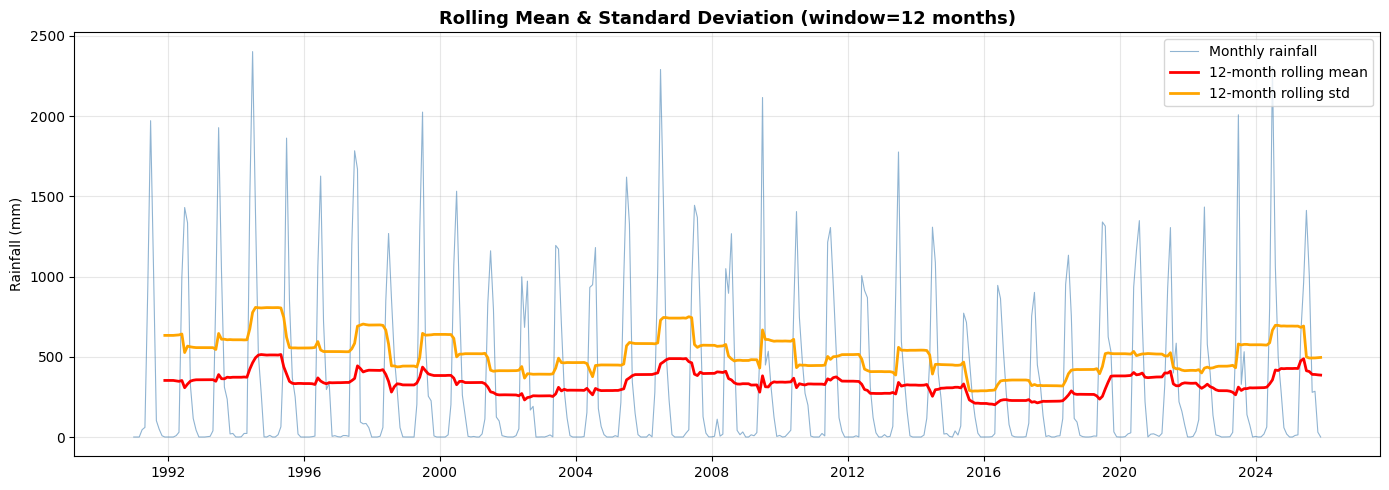

Rolling mean range : 201.1 to 514.2 mm
Rolling std range  : 285.9 to 807.7 mm


In [4]:
import matplotlib.pyplot as plt

rolling_mean = df['rainfall_mm'].rolling(window=12).mean()
rolling_std  = df['rainfall_mm'].rolling(window=12).std()

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['rainfall_mm'],
         color='steelblue', linewidth=0.8, alpha=0.6, label='Monthly rainfall')
plt.plot(df.index, rolling_mean,
         color='red', linewidth=2, label='12-month rolling mean')
plt.plot(df.index, rolling_std,
         color='orange', linewidth=2, label='12-month rolling std')
plt.title('Rolling Mean & Standard Deviation (window=12 months)',
          fontsize=13, fontweight='bold')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('03_rolling_mean_std.png', dpi=150)
plt.show()

print(f"Rolling mean range : {rolling_mean.min():.1f} to {rolling_mean.max():.1f} mm")
print(f"Rolling std range  : {rolling_std.min():.1f} to {rolling_std.max():.1f} mm")

In [5]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['rainfall_mm'].dropna())

print('='*45)
print('Augmented Dickey-Fuller Test')
print('='*45)
print(f'ADF Statistic  : {result[0]:.4f}')
print(f'p-value        : {result[1]:.6f}')
print(f'Lags used      : {result[2]}')
print(f'Observations   : {result[3]}')
print('\nCritical Values:')
for key, val in result[4].items():
    print(f'   {key}  :  {val:.4f}')

print('\n--- INTERPRETATION ---')
if result[1] <= 0.05:
    print('p-value <= 0.05')
    print('CONCLUSION: Series IS stationary')
    print('d = 0 (no differencing needed)')
else:
    print('p-value > 0.05')
    print('CONCLUSION: Series is NOT stationary')
    print('d = 1 (differencing needed)')

Augmented Dickey-Fuller Test
ADF Statistic  : -3.2009
p-value        : 0.019930
Lags used      : 13
Observations   : 406

Critical Values:
   1%  :  -3.4466
   5%  :  -2.8687
   10%  :  -2.5706

--- INTERPRETATION ---
p-value <= 0.05
CONCLUSION: Series IS stationary
d = 0 (no differencing needed)


In [6]:
with open('04_adf_test_results.txt', 'w') as f:
    f.write('Augmented Dickey-Fuller Test — Goa Monthly Rainfall\n')
    f.write('='*50 + '\n')
    f.write(f'ADF Statistic : {result[0]:.4f}\n')
    f.write(f'p-value       : {result[1]:.6f}\n')
    f.write(f'Lags used     : {result[2]}\n')
    f.write(f'Observations  : {result[3]}\n')
    f.write('\nCritical Values:\n')
    for key, val in result[4].items():
        f.write(f'  {key} : {val:.4f}\n')
    f.write('\nConclusion: Series is stationary at 5% level\n')
    f.write('d = 0 (no differencing needed)\n')
    f.write('D = 1 (seasonal differencing for 12-month cycle)\n')

print("Saved: 04_adf_test_results.txt")

Saved: 04_adf_test_results.txt
